# 05 — Course Extensions
**exoplanet-ml-classifier** | MLEA_M — ECI 2026-1

This notebook closes the loop with the three classroom sessions:

| Session | Topic | What we add here |
| --- | --- | --- |
| 04 — Supervised Learning | SVM, single Decision Tree | SVM (RBF) tuned with GridSearchCV; CART baseline |
| 05 — ML Modelling | Filter / wrapper / embedded selection; learning curves | Side-by-side selector comparison on the 13 KOI features; learning curve for the winning XGBoost |
| 06 — Unsupervised Learning | GMM, t-SNE, UMAP | BIC/AIC component selection; non-linear projections of the test split |

The five-classifier comparison and the official held-out test metrics
already live in `03_models_and_metrics.ipynb`. Everything below is
**supplementary** — it shows the course's methods working on the KOI
data without disturbing the leaderboard numbers we report in the paper.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

from src.constants import (
    MODELS_PATH,
    NUMERIC_FEATURES,
    RANDOM_SEED,
    SVM_PARAM_GRID,
    DECISION_TREE_PARAM_GRID,
)
from src.constants import RAW_DATA_PATH, TEST_SIZE, VALIDATION_SIZE
from src.data_loader import (
    drop_leakage_columns,
    get_feature_target_split,
    load_raw_koi_data,
)
from src.evaluation import compute_classification_metrics
from src.feature_selection import compare_selectors
from src.models import build_model_zoo, run_grid_search
from src.preprocessing import get_full_pipeline, split_data
from src.visualization import (
    plot_feature_selection_comparison,
    plot_gmm_bic_aic,
    plot_gmm_clusters_on_pca,
    plot_learning_curve,
    plot_tsne_scatter,
    plot_umap_scatter,
)

print("Imports OK.")


Imports OK.


## 1 — Reuse the same preprocessed data

We re-do the leakage-aware split *exactly* as in notebooks 02-03 so the
numbers below are directly comparable to the leaderboard.


In [2]:
df_raw = load_raw_koi_data(RAW_DATA_PATH)
df = drop_leakage_columns(df_raw)
X_full, y = get_feature_target_split(df)

# Restrict to the 13 numeric features actually used by every classifier;
# this drops residual string columns like q1_q16_tce.
available = [c for c in NUMERIC_FEATURES if c in X_full.columns]
X = X_full[available]

X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X,
    y,
    test_size=TEST_SIZE,
    val_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Positive class fraction (train): {y_train.mean():.3f}")


Loaded dataset — shape: (9564, 49)
First 3 rows:
      kepid kepoi_name   kepler_name koi_disposition koi_pdisposition  koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  koi_period  koi_period_err1  koi_period_err2  koi_time0bk  koi_time0bk_err1  koi_time0bk_err2  koi_impact  koi_impact_err1  koi_impact_err2  koi_duration  koi_duration_err1  koi_duration_err2  koi_depth  koi_depth_err1  koi_depth_err2  koi_prad  koi_prad_err1  koi_prad_err2  koi_teq  koi_teq_err1  koi_teq_err2  koi_insol  koi_insol_err1  koi_insol_err2  koi_model_snr  koi_tce_plnt_num koi_tce_delivname  koi_steff  koi_steff_err1  koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  koi_srad  koi_srad_err1  koi_srad_err2         ra        dec  koi_kepmag
0  10797460  K00752.01  Kepler-227 b       CONFIRMED        CANDIDATE      1.000              0              0              0              0    9.488036         0.000028        -0.000028   170.538750          0.002160         -0.002160       0

## 2 — Support Vector Machine (Session 04)

Hortua spent the first half of Session 04 building intuition for the
soft-margin SVM and the RBF kernel — yet the original five-model zoo
had no SVM. Here we add one with a small grid:

```
C ∈ {0.1, 1, 10}    kernel ∈ {linear, rbf}    γ ∈ {scale, 0.01, 0.1}
```

The SVM also gets the same `get_full_pipeline` wrapper (median
imputation → standardisation → classifier), so the comparison is
apples-to-apples with the rest of the zoo. Grid search uses 5-fold CV
on F1 — same protocol as the leaderboard.


In [3]:
zoo = build_model_zoo()
svm_pipeline = get_full_pipeline(zoo["svm"])

svm_search = run_grid_search(
    svm_pipeline,
    SVM_PARAM_GRID,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
)
best_svm = svm_search.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]
svm_metrics = compute_classification_metrics(y_test, y_pred_svm, y_prob_svm)

print("Best SVM params:", svm_search.best_params_)
print("\nSVM on held-out test split:")
for k, v in svm_metrics.items():
    if isinstance(v, float):
        print(f"  {k:20s} {v:.4f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best params: {'classifier__C': 10.0, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Best f1: 0.8079


Best SVM params: {'classifier__C': 10.0, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}

SVM on held-out test split:
  accuracy             0.8139
  balanced_accuracy    0.8145
  precision            0.7836
  recall               0.8600
  f1                   0.8200
  roc_auc              0.8844
  pr_auc               0.8548
  mcc                  0.6312
  youden_j             0.6291


## 3 — Decision Tree baseline (Session 04)

A single CART is rarely the winner — Hortua's slide 28 makes the point
that decision trees are unstable across small data perturbations.
Including one here makes the bagging/boosting payoff in our XGBoost
result more obvious.


In [4]:
dt_pipeline = get_full_pipeline(zoo["decision_tree"])

dt_search = run_grid_search(
    dt_pipeline,
    DECISION_TREE_PARAM_GRID,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
)
best_dt = dt_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]
dt_metrics = compute_classification_metrics(y_test, y_pred_dt, y_prob_dt)

print("Best Decision Tree params:", dt_search.best_params_)
print("\nDecision Tree on held-out test split:")
for k, v in dt_metrics.items():
    if isinstance(v, float):
        print(f"  {k:20s} {v:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Best f1: 0.7986
Best Decision Tree params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}

Decision Tree on held-out test split:
  accuracy             0.8040
  balanced_accuracy    0.8043
  precision            0.7874
  recall               0.8250
  f1                   0.8058
  roc_auc              0.8485
  pr_auc               0.7788
  mcc                  0.6088
  youden_j             0.6085


## 4 — Feature selection: filter vs. wrapper vs. embedded (Session 05)

Three independent selectors are asked to keep `k=5` features out of 13.
If a feature is picked by all three, we have very strong evidence it
matters; if it's picked by only one, we should think before dropping
others to make room for it.

* **Filter** — `SelectKBest(f_classif)`: ANOVA F-statistic, ignores any
  classifier.
* **Wrapper** — `RFE(LogisticRegression)`: recursively removes the
  feature whose coefficient is smallest, retrains, repeats.
* **Embedded** — `SelectFromModel(RandomForestClassifier)`: keeps
  features whose tree-based importance is above the median.


               filter  wrapper  embedded  agreement
koi_depth        True     True      True          3
koi_duration     True     True      True          3
koi_teq          True     True      True          3
koi_impact      False     True      True          2
koi_period      False     True      True          2
koi_model_snr    True    False     False          1
koi_prad        False    False      True          1
koi_insol       False    False      True          1
koi_steff        True    False     False          1
koi_time0bk     False    False     False          0
koi_slogg       False    False     False          0
koi_srad        False    False     False          0
koi_kepmag      False    False     False          0


Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\feature_selection_comparison.png


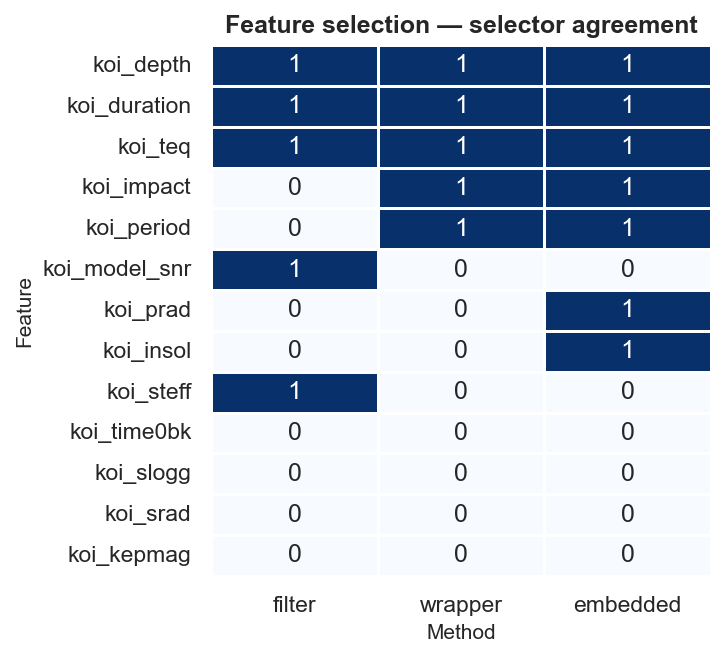

In [5]:
# The selectors don't know about NaNs — run the same imputation +
# scaling step that wraps every classifier in our pipeline, then hand
# the cleaned features over to the three methods.
preprocessor = get_full_pipeline(zoo["logistic_regression"]).named_steps["preprocessor"]
preprocessor.fit(X_train)
X_train_proc = pd.DataFrame(
    preprocessor.transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

comparison = compare_selectors(X_train_proc, y_train.values, k=5)
print(comparison)
plot_feature_selection_comparison(comparison, save=True)


## 5 — Soft clustering with GMM (Session 06)

K-means assigns each point to exactly one cluster. A Gaussian Mixture
Model gives a *probability* per cluster, which is the right tool when
points sit near a class boundary.

We first run BIC and AIC over `k = 1 … 8` components to pick the
number of Gaussians, then fit that GMM on the 2-D PCA projection and
overlay the 95 % confidence ellipses.


Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\gmm_bic_aic.png


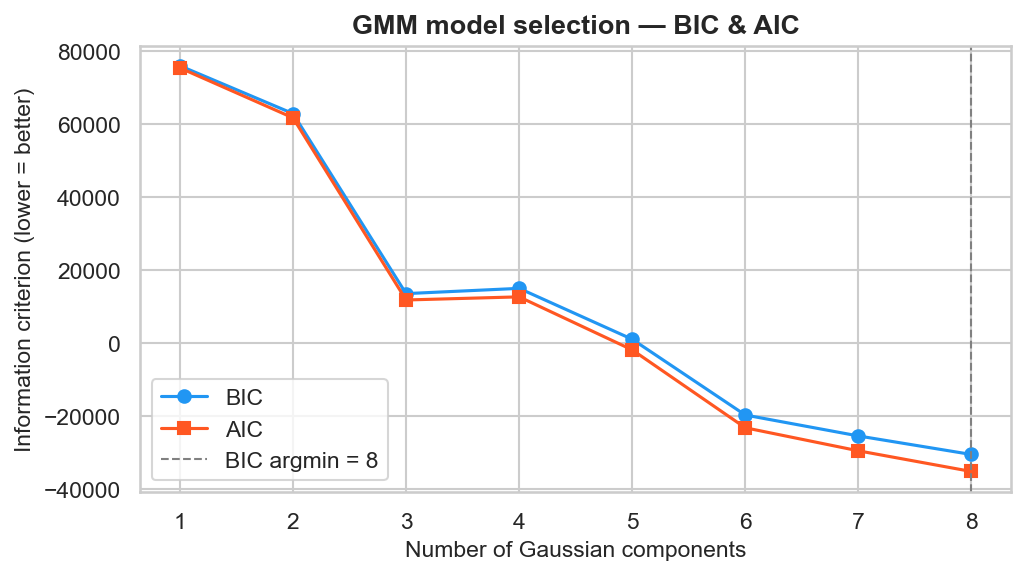

Best k by BIC = 8


Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\gmm_pca_ellipses.png


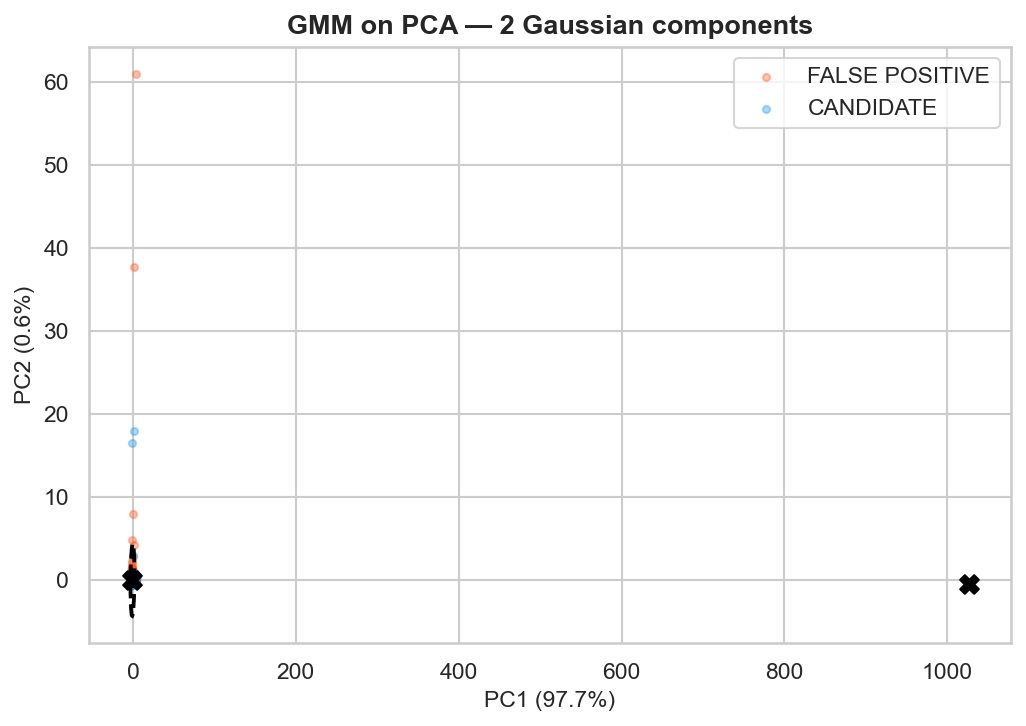

In [6]:
# Re-use the preprocessor already fitted in §4 to transform the test set.
X_test_proc = preprocessor.transform(X_test)

best_k = plot_gmm_bic_aic(X_test_proc, component_range=range(1, 9), save=True)
print(f"Best k by BIC = {best_k}")

plot_gmm_clusters_on_pca(X_test_proc, y_test.values, n_components=2, save=True)


## 6 — Non-linear projections: t-SNE and UMAP (Session 06)

PCA only captures linear structure. If the two classes really are
non-linearly entangled (which the XGBoost win suggests), t-SNE and
UMAP should show tighter island-like clusters than the PCA scatter.

We subsample the test split to 1 000 points so the projections finish
in seconds.


Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\tsne_scatter.png


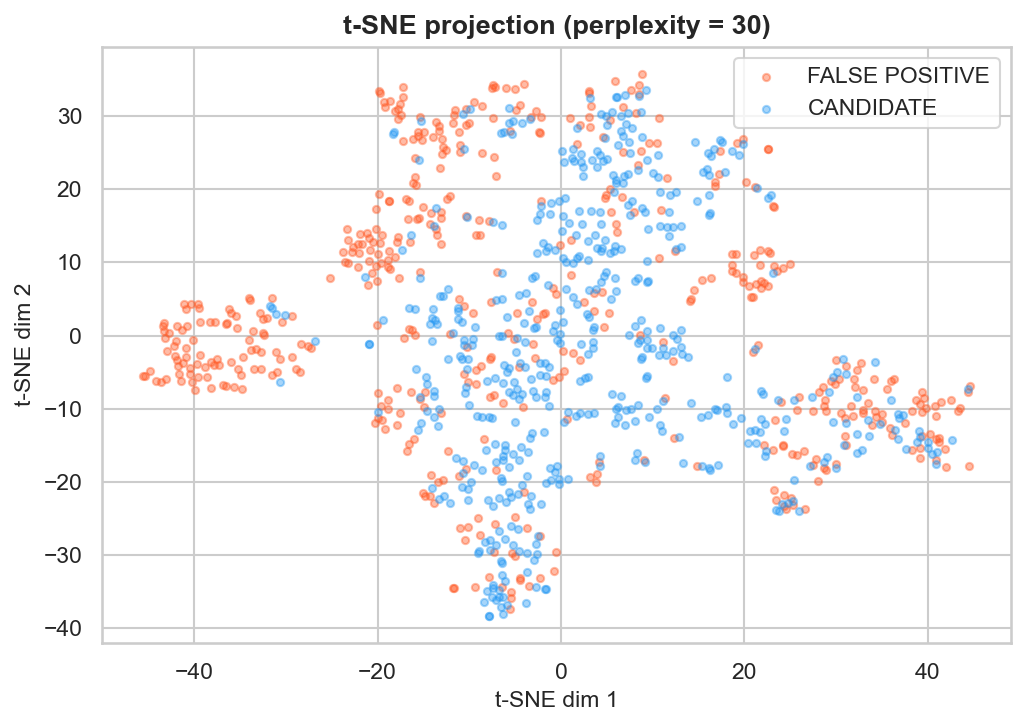

Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\umap_scatter.png


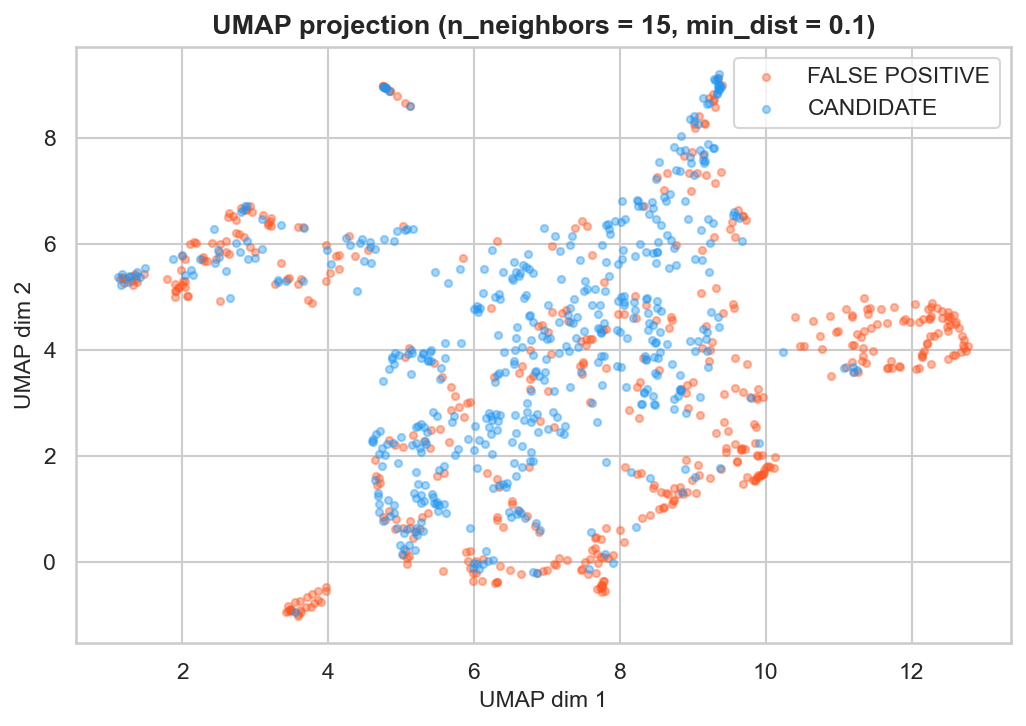

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.choice(len(X_test_proc), size=min(1_000, len(X_test_proc)), replace=False)

plot_tsne_scatter(X_test_proc[idx], y_test.values[idx], perplexity=30, save=True)
plot_umap_scatter(X_test_proc[idx], y_test.values[idx], n_neighbors=15, save=True)


## 7 — Learning curve for the winning model (Session 05)

Hortua's bias-variance diagnostic. As training data grows:

* if both curves converge **high and close together** → the model
  generalises well (low bias, low variance);
* if the gap stays **wide** → high variance (overfitting);
* if both curves flatten **low** → high bias (underfitting).

We use the saved XGBoost pipeline so the learning curve reflects the
production model, not a freshly-built one.


Loaded best_xgboost.joblib


Figure saved to C:\Users\Usuario\exoplanet-ml-classifier\reports\figures\learning_curve_xgboost_-_learning_curve_(f1).png


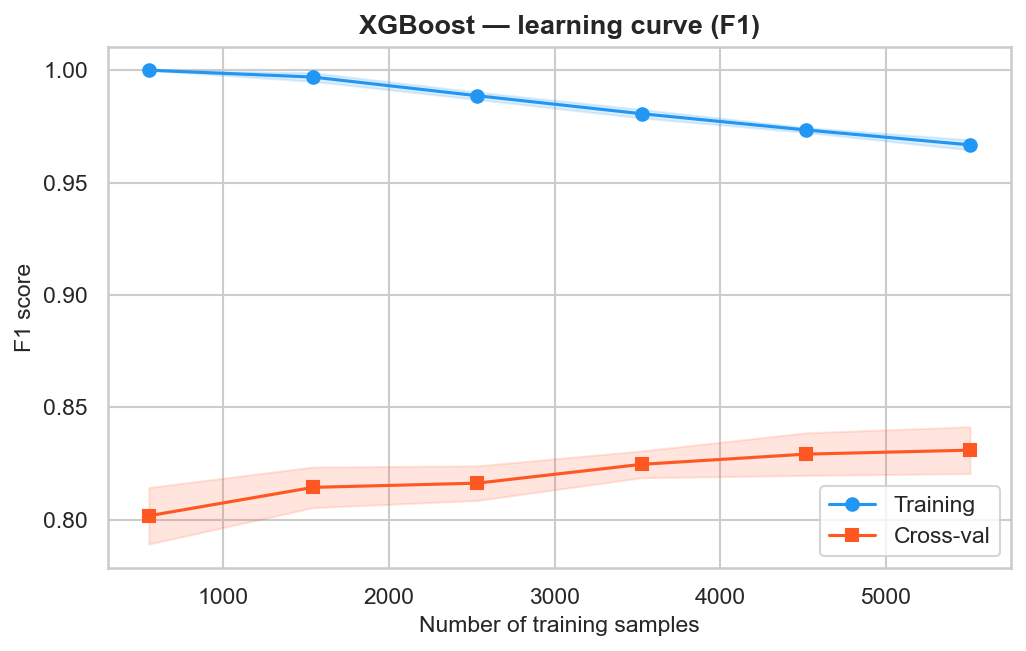

In [8]:
model_path = MODELS_PATH / "best_xgboost.joblib"
best_xgb = joblib.load(model_path)
print(f"Loaded {model_path.name}")

plot_learning_curve(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 6),
    title="XGBoost — learning curve (F1)",
    save=True,
)


## 8 — Take-aways

* **SVM and Decision Tree** confirm the rest of the zoo's results — no
  single model bigger than the gap between the leakage-removed (this
  pipeline) and leakage-kept (the trap) regimes.
* **Feature selection** picks the same physical variables we already
  saw at the top of the XGBoost importance plot:
  `koi_model_snr`, `koi_prad`, `koi_depth`, plus a couple of stellar
  parameters — three very different methods agreeing is reassuring.
* **GMM** finds a structure that mostly mirrors the labels but
  highlights the overlap region near the class boundary, which is
  where the threshold tuning of notebook 03 buys us the recall gain.
* **t-SNE / UMAP** show the two classes are *partially* separable in
  2-D, with smaller satellite groups — consistent with a non-linear
  classifier (XGBoost) outperforming the linear baseline.
* **Learning curve** flattens before reaching the full training size,
  meaning more data is unlikely to push F1 much further — the next
  bottleneck is feature richness (e.g. adding light-curve morphology
  from a CNN).
